### 1. Pemahaman Masalah
Bank Sentral Taiwan memiliki tanggung jawab penting dalam menjaga stabilitas sistem keuangan nasional serta memastikan seluruh lembaga perbankan berada dalam kondisi sehat. Salah satu tantangan utama yang dihadapi adalah risiko kebangkrutan (bankruptcy) yang dapat terjadi pada bank-bank komersial. Jika hal ini tidak terdeteksi sejak dini, dampaknya bisa meluas ke sistem keuangan secara keseluruhan, menimbulkan ketidakpercayaan publik, penarikan dana besar-besaran (bank run), dan bahkan krisis ekonomi.

Selama ini, penilaian kesehatan bank dilakukan secara konvensional melalui analisis laporan keuangan dan rasio-rasio seperti ROA, ROE, Debt to Equity, dan lain-lain. Namun, metode tersebut bersifat reaktif, karena hasilnya baru terlihat setelah masalah muncul. Oleh sebab itu, Bank Sentral perlu beralih ke pendekatan yang lebih prediktif dan berbasis data historis, agar potensi kebangkrutan dapat dideteksi sebelum benar-benar terjadi. 
Melalui penerapan predictive analytics menggunakan model machine learning, Bank Sentral dapat:

- Mengidentifikasi pola atau indikator keuangan yang menjadi tanda awal kebangkrutan,
- Menghitung tingkat risiko kebangkrutan setiap bank,
- Memberikan peringatan dini bagi bank yang berisiko tinggi, dan
- Menyusun kebijakan pengawasan serta intervensi yang lebih tepat sasaran.

Dengan demikian, proyek ini akan membantu Bank Sentral beralih dari pendekatan pengawasan manual ke sistem pengawasan berbasis data dan otomatis, meningkatkan efisiensi serta efektivitas pengambilan keputusan.
Hasil dari model prediksi ini juga dapat digunakan sebagai dasar dalam pembuatan kebijakan preventif, menjaga kesehatan industri perbankan, dan memastikan stabilitas keuangan nasional tetap terjaga. 

In [20]:
# Import library dasar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
# Load dataset
df = pd.read_csv('C:/Users/acer/data-bank.csv')

In [22]:
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [23]:
df.shape

(6819, 96)

In [24]:
df.tail()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009
6818,0,0.493053,0.570105,0.549548,0.627409,0.627409,0.998080,0.801987,0.813800,0.313415,...,0.815956,0.000707,0.626680,0.627408,0.841019,0.275114,0.026793,0.565167,1,0.233902


In [25]:
# Cek informasi umum dan missing values
print("\nInformasi dataset:")
print(df.info())
print("\nJumlah missing value tiap kolom:")
print(df.isnull().sum().sort_values(ascending=False).head())


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8 

In [26]:
# Tentukan target variable
target = 'Bankrupt?'
print("\nDistribusi Target Variable:")
print(df[target].value_counts())


Distribusi Target Variable:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64


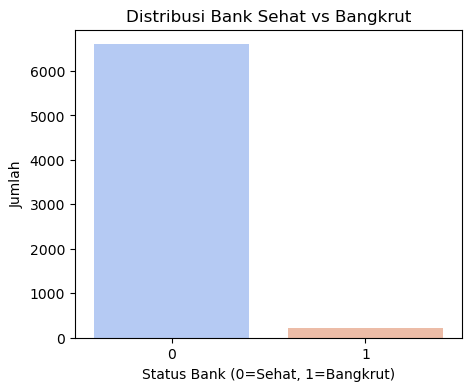

In [27]:
# Visualisasi distribusi target
plt.figure(figsize=(5,4))
sns.countplot(x=target, hue=target, data=df, palette='coolwarm', legend=False)
plt.title("Distribusi Bank Sehat vs Bangkrut")
plt.xlabel("Status Bank (0=Sehat, 1=Bangkrut)")
plt.ylabel("Jumlah")
plt.show()

In [28]:
# Hitung korelasi antara fitur numerik dan target
numeric_features = df.select_dtypes(include=[np.number]).drop(columns=[target])
corr_with_target = numeric_features.corrwith(df[target]).sort_values(ascending=False)
top_corr = corr_with_target.head(10)

print("\n10 Variabel dengan korelasi tertinggi terhadap kebangkrutan:")
display(top_corr)


10 Variabel dengan korelasi tertinggi terhadap kebangkrutan:


C:\Users\acer\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\acer\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Debt ratio %                           0.250161
Current Liability to Assets            0.194494
Borrowing dependency                   0.176543
Current Liability to Current Assets    0.171306
Liability to Equity                    0.166812
Current Liabilities/Equity             0.153828
Current Liability to Equity            0.153828
Liability-Assets Flag                  0.139212
Total expense/Assets                   0.139049
Equity to Long-term Liability          0.139014
dtype: float64

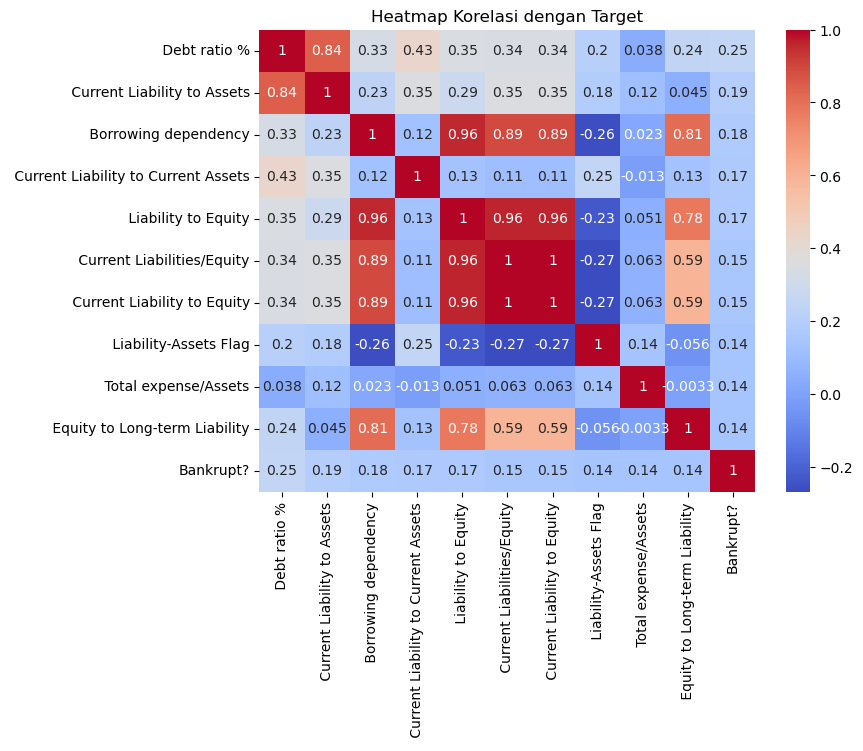

In [29]:
# Visualisasi heatmap korelasi top features
plt.figure(figsize=(8,6))
sns.heatmap(df[top_corr.index.tolist() + [target]].corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi dengan Target")
plt.show()

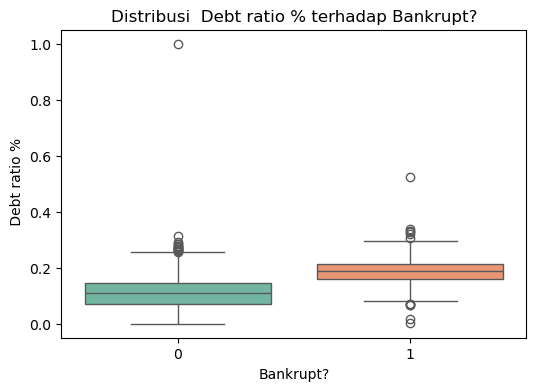

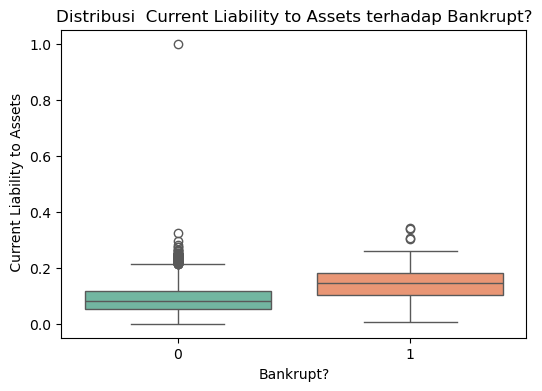

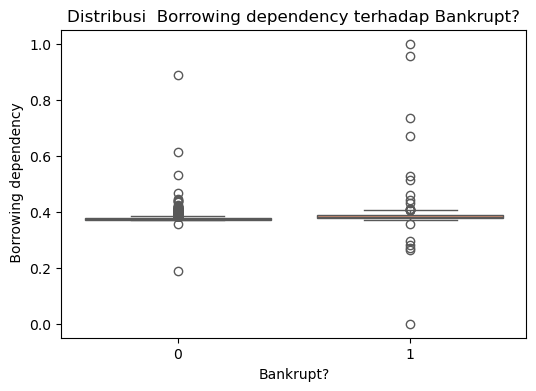

In [30]:
# Scatter plot 3 fitur utama terhadap target
top3 = top_corr.index[:3]
for feature in top3:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target, y=feature, hue=target, data=df, palette='Set2', legend=False)
    plt.title(f"Distribusi {feature} terhadap Bankrupt?")
    plt.show()

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [32]:
# Cek ulang missing values
print("Jumlah missing value per kolom:")
print(df.isnull().sum().sort_values(ascending=False).head(96))

Jumlah missing value per kolom:
Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64


In [33]:
# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=[target])
y = df[target]


Distribusi target sebelum balancing:
Bankrupt?
0    0.967737
1    0.032263
Name: proportion, dtype: float64


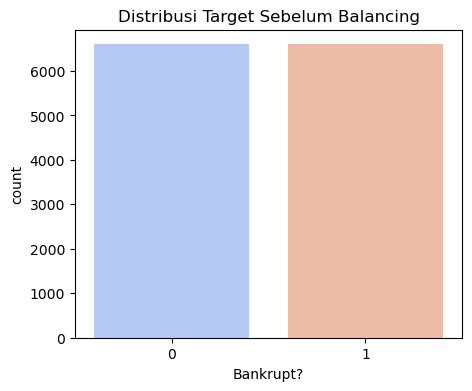

In [34]:
# Cek apakah data balance atau tidak
print("\nDistribusi target sebelum balancing:")
print(y.value_counts(normalize=True))

plt.figure(figsize=(5,4))
sns.countplot(x=y_res, hue=y_res, palette='coolwarm', legend=False)
plt.title("Distribusi Target Sebelum Balancing")
plt.show()


Distribusi target setelah SMOTE (balancing):
Bankrupt?
1    0.5
0    0.5
Name: proportion, dtype: float64


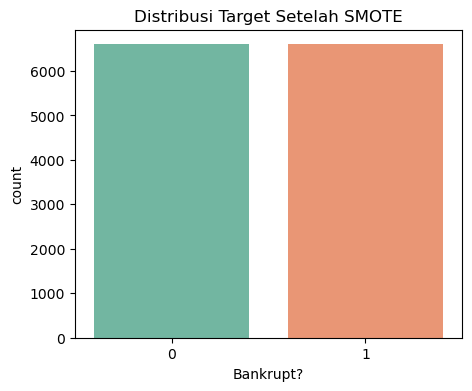

In [35]:
# Tangani data tidak seimbang dengan SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print("\nDistribusi target setelah SMOTE (balancing):")
print(y_res.value_counts(normalize=True))

plt.figure(figsize=(5,4))
sns.countplot(x=y_res, hue=y_res, palette='Set2', legend=False)
plt.title("Distribusi Target Setelah SMOTE")
plt.show()

In [36]:
# Split data menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

print("\nUkuran data train:", X_train.shape)
print("Ukuran data test:", X_test.shape)


Ukuran data train: (10558, 95)
Ukuran data test: (2640, 95)


In [37]:
# Normalisasi (standarisasi) fitur numerik
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Modelling & Evaluation

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

=== Decision Tree Performance ===
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1320
           1       0.94      0.97      0.95      1320

    accuracy                           0.95      2640
   macro avg       0.95      0.95      0.95      2640
weighted avg       0.95      0.95      0.95      2640

Akurasi Decision Tree: 0.95


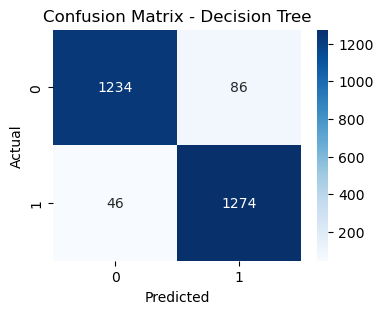

In [39]:
# Inisialisasi model Decision Tree
dt = DecisionTreeClassifier(random_state=42)

# Training model
dt.fit(X_train_scaled, y_train)

# Prediksi data test
y_pred_dt = dt.predict(X_test_scaled)

# Evaluasi
print("=== Decision Tree Performance ===")
print(classification_report(y_test, y_pred_dt))
print("Akurasi Decision Tree:", accuracy_score(y_test, y_pred_dt))

# Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== Random Forest Performance ===
              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1320
           1       0.96      0.99      0.98      1320

    accuracy                           0.98      2640
   macro avg       0.98      0.98      0.98      2640
weighted avg       0.98      0.98      0.98      2640

Akurasi Random Forest: 0.9787878787878788


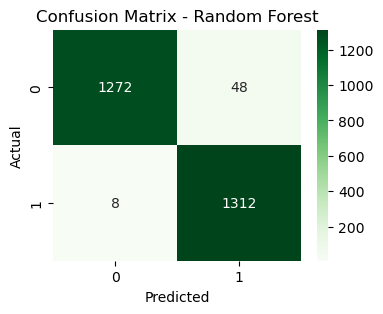

In [41]:
# Inisialisasi model
rf = RandomForestClassifier(
    n_estimators=100,       # jumlah pohon
    max_depth=None,         # kedalaman pohon
    random_state=42
)

# Training
rf.fit(X_train_scaled, y_train)

# Prediksi
y_pred_rf = rf.predict(X_test_scaled)

# Evaluasi
print("=== Random Forest Performance ===")
print(classification_report(y_test, y_pred_rf))
print("Akurasi Random Forest:", accuracy_score(y_test, y_pred_rf))

# Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

=== Artificial Neural Network (ANN) Performance ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.97      0.99      0.98      1320

    accuracy                           0.98      2640
   macro avg       0.98      0.98      0.98      2640
weighted avg       0.98      0.98      0.98      2640

Akurasi ANN: 0.984469696969697


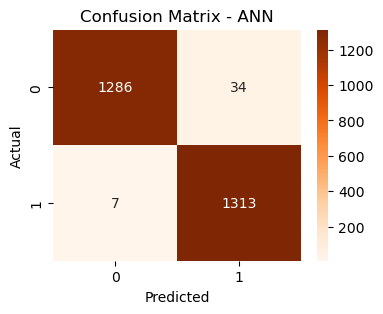

In [42]:
# Inisialisasi model
ann = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 hidden layer
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# Training
ann.fit(X_train_scaled, y_train)

# Prediksi
y_pred_ann = ann.predict(X_test_scaled)

# Evaluasi
print("=== Artificial Neural Network (ANN) Performance ===")
print(classification_report(y_test, y_pred_ann))
print("Akurasi ANN:", accuracy_score(y_test, y_pred_ann))

# Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_ann), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Hasil Analisis
Berdasarkan hasil evaluasi ketiga model (Decision Tree, Random Forest, dan Artificial Neural Network), Random Forest menjadi model paling sesuai untuk memprediksi potensi kebangkrutan bank.
Random Forest memberikan kombinasi terbaik antara akurasi tinggi, generalisasi kuat, dan interpretabilitas yang dapat diterima, sehingga cocok untuk digunakan Bank Sentral dalam proses pengawasan dan deteksi dini bank bermasalah.

### 5 variable yang paling mempengaruhi kebangkrutan sebuah bank


5 Variabel Paling Berpengaruh (Random Forest):
After-tax net Interest Rate             0.055149
Retained Earnings to Total Assets       0.053361
Continuous interest rate (after tax)    0.051013
Net Income to Total Assets              0.049218
Total debt/Total net worth              0.046062
dtype: float64


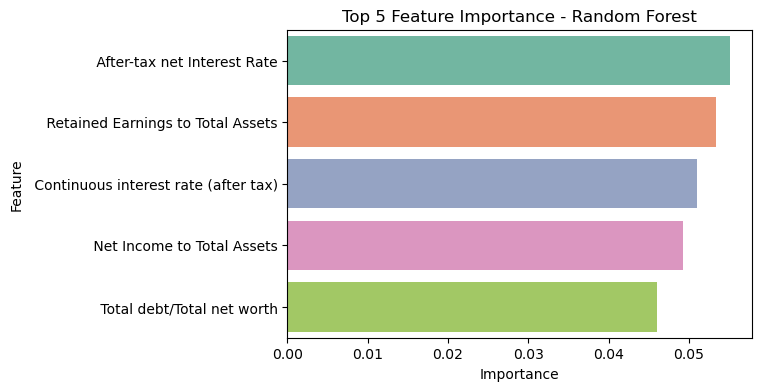

In [44]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
top5_rf = importance.sort_values(ascending=False).head(5)

print("\n5 Variabel Paling Berpengaruh (Random Forest):")
print(top5_rf)

plt.figure(figsize=(6,4))
sns.barplot(x=top5_rf.values, y=top5_rf.index, hue=top5_rf.index, palette='Set2', legend=False)
plt.title("Top 5 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()